In [1]:
import pandas as pd
import seaborn as sns
import pyspark.sql.functions as f
from pyspark.sql import SparkSession
from pyspark.ml.feature import SQLTransformer, StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline

from IPython.display import display

In [2]:
spark = SparkSession.builder\
    .appName("XGBoostApp")\
    .master("local[*]")\
    .config("spark.executor.memory", "4g")\
    .config("spark.driver.memory", "4g")\
    .getOrCreate()

In [3]:
spark.sparkContext

<SparkContext master=local[*] appName=XGBoostApp>

In [4]:
# pip install xgboost

In [5]:
target = 'Diagnosis'

In [6]:
df = spark.read.option("header", "true")\
               .option("inferSchema", "true")\
               .option("delimiter", ",")\
               .csv("The_Cancer_data_1500_V2.csv")

agg_tab = df.agg(f.count(target).alias('count'),
            f.sum(target).alias(f'sum_{target}'),
            f.mean(target).alias(f'mean_{target}'),
            ).toPandas()

display(agg_tab)

,count,sum_Diagnosis,mean_Diagnosis
0,1500,557,0.371333


In [7]:
# Splitting the DataFrame into training and testing sets with stratified sampling
strata = target

strata_list = df.select(strata).distinct().orderBy(strata).rdd.flatMap(lambda x: x).collect()
stratified_dfs = []

train_df = df.limit(0)
test_df = df.limit(0)

for s in strata_list:
    stratified_df = df.filter(df[strata] == s)
    train_strata, test_strata = stratified_df.randomSplit([0.7, 0.3], seed = 42)
    train_df = train_df.union(train_strata)
    test_df = test_df.union(test_strata)

In [8]:
agg_tab1 = train_df.agg(f.count(target).alias('count'),
            f.sum(target).alias(f'sum_{target}'),
            f.mean(target).alias(f'mean_{target}'),
            ).toPandas()

agg_tab1['dataset'] = 'train'

agg_tab2 = test_df.agg(f.count(target).alias('count'),
            f.sum(target).alias(f'sum_{target}'),
            f.mean(target).alias(f'mean_{target}'),
            ).toPandas()

agg_tab2['dataset'] = 'test'

agg_tab = pd.concat([agg_tab1, agg_tab2], ignore_index=True)
cols = ['dataset'] + [col for col in agg_tab.columns if col != 'dataset']

display(agg_tab[cols])

,dataset,count,sum_Diagnosis,mean_Diagnosis
0,train,1117,416,0.372426
1,test,383,141,0.368146


In [9]:
sql_query = """
SELECT Age
, CASE WHEN Gender = 1 THEN 'Y' ELSE 'N' END AS Gender
, BMI
, CASE WHEN Smoking = 1 THEN 'Y' ELSE 'N' END AS Smoking
, CASE WHEN GeneticRisk = 0 THEN 'Low'
       WHEN GeneticRisk = 1 THEN 'Medium' 
       ELSE 'High' END AS GeneticRisk
, PhysicalActivity
, AlcoholIntake
, CASE WHEN CancerHistory = 1 THEN 'Y' ELSE 'N' END AS CancerHistory
, Diagnosis       
FROM __THIS__"""

sql_transformer = SQLTransformer(statement=sql_query)
sqltrans_df = sql_transformer.transform(train_df)
display(sqltrans_df.limit(10).toPandas())

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,20,N,15.438809,N,Medium,3.831645,0.338982,N,0
1,20,N,16.985165,Y,Medium,9.068666,1.981237,Y,0
2,20,N,21.884529,N,Medium,4.346781,1.940665,N,0
3,20,N,22.438711,N,Low,9.678646,3.236111,Y,0
4,20,N,22.489142,N,Medium,2.469654,2.968529,N,0
5,20,N,26.481630,N,Medium,8.985969,1.518619,N,0
6,20,N,32.203368,Y,Low,2.556662,1.705239,N,0
7,20,N,35.148135,N,Low,8.364397,2.639061,N,0
8,20,N,35.887006,N,Low,4.095609,4.040785,N,0
9,20,Y,16.441190,N,Low,8.824951,0.587379,N,0


In [10]:
indexer = StringIndexer(inputCols = ['Gender', 'Smoking', 'GeneticRisk', 'CancerHistory'], 
                        outputCols = ['GenderIndexer', 'SmokingIndexer', 'GeneticRiskIndexer', 'CancerHistoryIndexer'])

indexer_df = indexer.fit(sqltrans_df).transform(sqltrans_df)
display(indexer_df.limit(10).toPandas())

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis,GenderIndexer,SmokingIndexer,GeneticRiskIndexer,CancerHistoryIndexer
0,20,N,15.438809,N,Medium,3.831645,0.338982,N,0,0.0,0.0,1.0,0.0
1,20,N,16.985165,Y,Medium,9.068666,1.981237,Y,0,0.0,1.0,1.0,1.0
2,20,N,21.884529,N,Medium,4.346781,1.940665,N,0,0.0,0.0,1.0,0.0
3,20,N,22.438711,N,Low,9.678646,3.236111,Y,0,0.0,0.0,0.0,1.0
4,20,N,22.489142,N,Medium,2.469654,2.968529,N,0,0.0,0.0,1.0,0.0
5,20,N,26.481630,N,Medium,8.985969,1.518619,N,0,0.0,0.0,1.0,0.0
6,20,N,32.203368,Y,Low,2.556662,1.705239,N,0,0.0,1.0,0.0,0.0
7,20,N,35.148135,N,Low,8.364397,2.639061,N,0,0.0,0.0,0.0,0.0
8,20,N,35.887006,N,Low,4.095609,4.040785,N,0,0.0,0.0,0.0,0.0
9,20,Y,16.441190,N,Low,8.824951,0.587379,N,0,1.0,0.0,0.0,0.0


In [11]:
from xgboost.spark import SparkXGBClassifier

feature_names = ['Age', 'GenderIndexer', 'BMI', 'SmokingIndexer', 'GeneticRiskIndexer',  
                 'PhysicalActivity', 'AlcoholIntake', 'CancerHistoryIndexer']

xgb_clf = SparkXGBClassifier(
    features_col = feature_names,
    label_col = target,
    n_estimators = 1,
    max_depth = 7,
    learning_rate = 0.1,
    num_workers = spark.sparkContext.defaultParallelism,
    use_gpu = True
)

pipeline = Pipeline(stages=[sql_transformer, indexer, xgb_clf])
model = pipeline.fit(train_df)

2026-03-28 16:46:56,878 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 4 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 7, 'use_gpu': True, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 1}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-28 16:47:03,666 INFO XGBoost-PySpark: _fit Finished xgboost training!


,Feature,Importance
6,AlcoholIntake,7.0
0,Age,6.0
2,BMI,6.0
5,PhysicalActivity,6.0
3,SmokingIndexer,5.0
1,GenderIndexer,4.0
4,GeneticRiskIndexer,1.0
7,CancerHistoryIndexer,1.0


<Axes: xlabel='Importance', ylabel='Feature'>

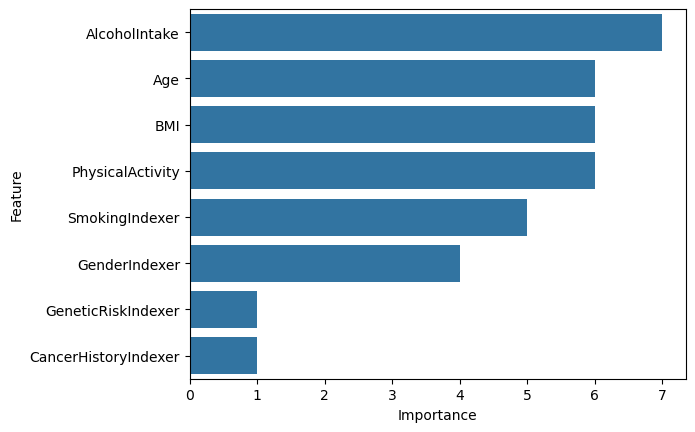

In [12]:
booster = model.stages[-1].get_booster()

feature_importances = booster.get_score()

df_feature_importances = pd.DataFrame(zip(feature_importances.keys(), feature_importances.values()), columns = ['Feature', 'Importance'])
df_feature_importances = df_feature_importances.sort_values('Importance', ascending = False)

display(df_feature_importances)

sns.barplot(df_feature_importances, x="Importance", y="Feature", estimator="sum", errorbar=None, orient="y")

<Axes: xlabel='BMI_bin', ylabel='mean_Diagnosis'>

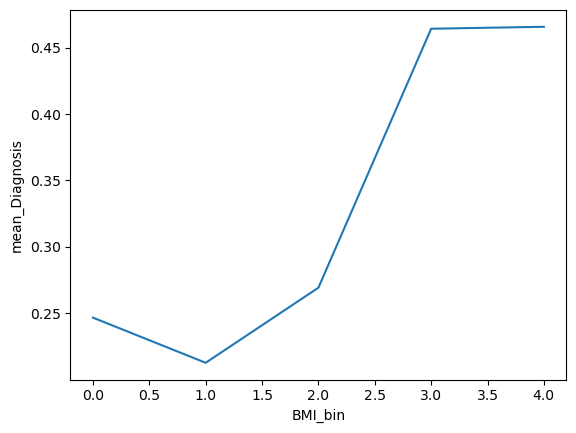

In [13]:
from pyspark.ml.feature import Bucketizer

df_split = booster.get_split_value_histogram(feature = "BMI")
df_split_list = df_split['SplitValue'].to_list()
df_split_list.sort()

splits = [float('-inf')] + df_split_list + [float('inf')]

bucketizer = Bucketizer(splits=splits, inputCol = "BMI", outputCol = "BMI_bin")
df_train_binned = bucketizer.transform(train_df)

pd_train_binned = df_train_binned.groupBy("BMI_bin")\
        .agg(f.mean(target).alias(f'mean_{target}'))\
        .toPandas()

sns.lineplot(data = pd_train_binned, x= "BMI_bin", y= f'mean_{target}')

In [14]:
from xgboost.spark import SparkXGBClassifier

feature_names = ['Age', 'GenderIndexer', 'BMI', 'SmokingIndexer', 'GeneticRiskIndexer',  
                 'PhysicalActivity', 'AlcoholIntake', 'CancerHistoryIndexer']

xgb_clf = SparkXGBClassifier(
    features_col = feature_names,
    label_col = target,
    n_estimators = 100,
    max_depth = 7,
    learning_rate = 0.1,
    num_workers = spark.sparkContext.defaultParallelism,
    use_gpu = True
)

pipeline = Pipeline(stages=[sql_transformer, indexer, xgb_clf])
model = pipeline.fit(train_df)

2026-03-28 16:47:05,145 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 4 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 7, 'use_gpu': True, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-28 16:47:09,738 INFO XGBoost-PySpark: _fit Finished xgboost training!


In [15]:
from pyspark.ml.functions import vector_to_array

predict_df = model.transform(test_df)

predict_df = predict_df.withColumn("prob_array", vector_to_array("probability")) \
    .withColumn("probability_0", f.col("prob_array")[0]) \
    .withColumn("probability_1", f.col("prob_array")[1]) \
    .drop("rawPrediction", "prob_array")

predict_df = predict_df.withColumn("prediction", f.col("prediction").cast("int"))

display(predict_df.select(target, "prediction", "probability", "probability_0", "probability_1").limit(10).toPandas())

,Diagnosis,prediction,probability,probability_0,probability_1
0,0,0,"[0.9981842637062073, 0.0018157362937927246]",0.998184,0.001816
1,0,0,"[0.998001754283905, 0.0019982345402240753]",0.998002,0.001998
2,0,0,"[0.9947486519813538, 0.005251321010291576]",0.994749,0.005251
3,0,0,"[0.9960020780563354, 0.00399791169911623]",0.996002,0.003998
4,0,0,"[0.8431196212768555, 0.15688037872314453]",0.843120,0.156880
5,0,0,"[0.9185786247253418, 0.0814213752746582]",0.918579,0.081421
6,0,0,"[0.9855566024780273, 0.014443378895521164]",0.985557,0.014443
7,0,0,"[0.9573169350624084, 0.042683038860559464]",0.957317,0.042683
8,0,0,"[0.9837895035743713, 0.016210511326789856]",0.983790,0.016211
9,0,0,"[0.9570640921592712, 0.04293593019247055]",0.957064,0.042936


In [16]:
predictionAndTarget = predict_df.select(f.col('probability_1').cast('double'), f.col(target).cast('double'))

evaluator = BinaryClassificationEvaluator(
    labelCol = target,
    rawPredictionCol = "probability_1",
    metricName = "areaUnderROC"
)

auc = evaluator.evaluate(predictionAndTarget)
gini = 2.0 * auc - 1.0
print(f"Gini: {gini:.6f}")

Gini: 0.883770


In [17]:
display(predict_df.crosstab(target, "prediction").toPandas())

,Diagnosis_prediction,0,1
0,0,233,9
1,1,24,117
